## Import Library

In [1]:
# ==================================================
# IMPORT LIBRARY
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Data Selection

In [2]:
# ==================================================
# KDD 1 - DATA SELECTION
# Upload Dataset dari Komputer
# ==================================================

from google.colab import files
import pandas as pd

# Upload file CSV
uploaded = files.upload()

Saving Depression Student Dataset.csv to Depression Student Dataset.csv


In [3]:
# Membaca file yang diupload
df = pd.read_csv('Depression Student Dataset.csv')

# Menampilkan 5 data pertama
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


### Informasi Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [5]:
df.describe()

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


### Cek Target

In [6]:
df['Depression'].value_counts()

,count
Depression,
Yes,252
No,250


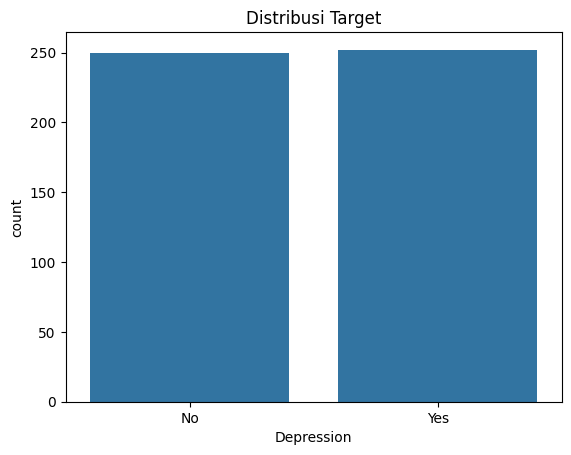

In [7]:
sns.countplot(data=df, x='Depression')
plt.title("Distribusi Target")
plt.show()

## Preprocessing

### Missing Value

In [8]:
# ==================================================
# CEK MISSING VALUE
# ==================================================

df.isnull().sum()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3394/1196867952.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3394/1196867952.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

### Duplicate Data

In [9]:
# ==================================================
# CEK DUPLIKAT
# ==================================================

print("Data Sebelum :", len(df))

df = df.drop_duplicates()

print("Data Sesudah :", len(df))

Data Sebelum : 502
Data Sesudah : 502


### Outlier Detection

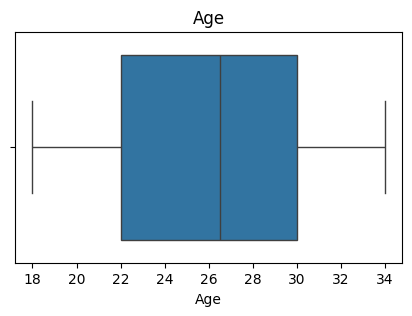

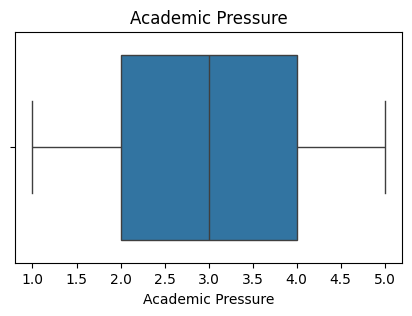

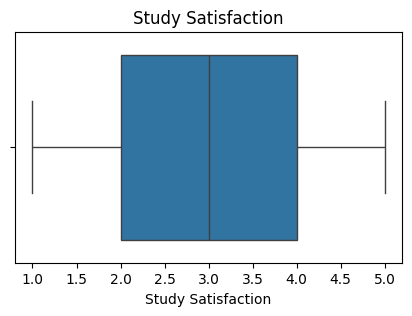

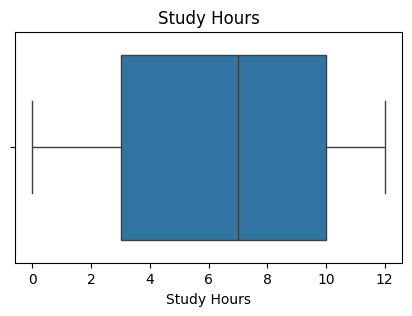

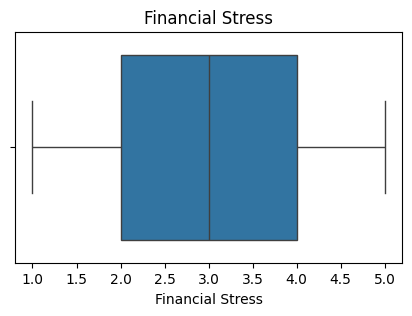

In [10]:
numeric_cols = [
    'Age',
    'Academic Pressure',
    'Study Satisfaction',
    'Study Hours',
    'Financial Stress'
]

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Menghapus Outlier dengan IQR

In [11]:
def remove_outlier_iqr(data,column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

for col in numeric_cols:
    df = remove_outlier_iqr(df,col)

print(df.shape)

(502, 11)


## Exploratory Data Analysis (EDA)

### Distribusi Umur

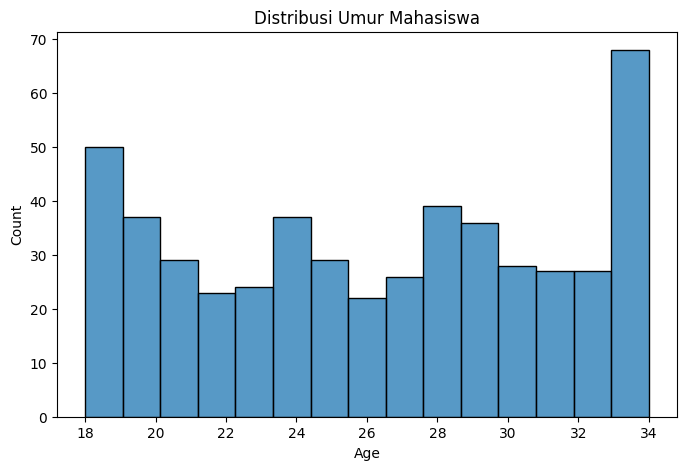

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15)

plt.title("Distribusi Umur Mahasiswa")

plt.show()

### Academic Pressure

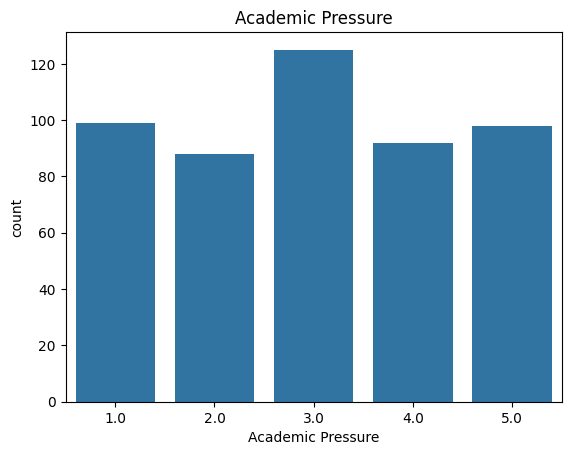

In [13]:
sns.countplot(
    data=df,
    x='Academic Pressure'
)

plt.title("Academic Pressure")

plt.show()

### Financial Stress

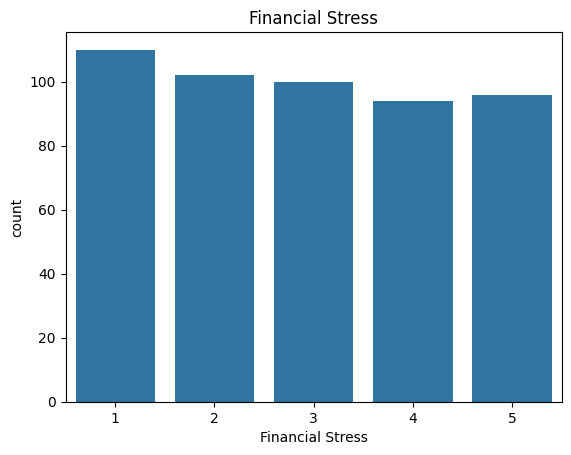

In [14]:
sns.countplot(
    data=df,
    x='Financial Stress'
)

plt.title("Financial Stress")

plt.show()

### Korelasi Numerik

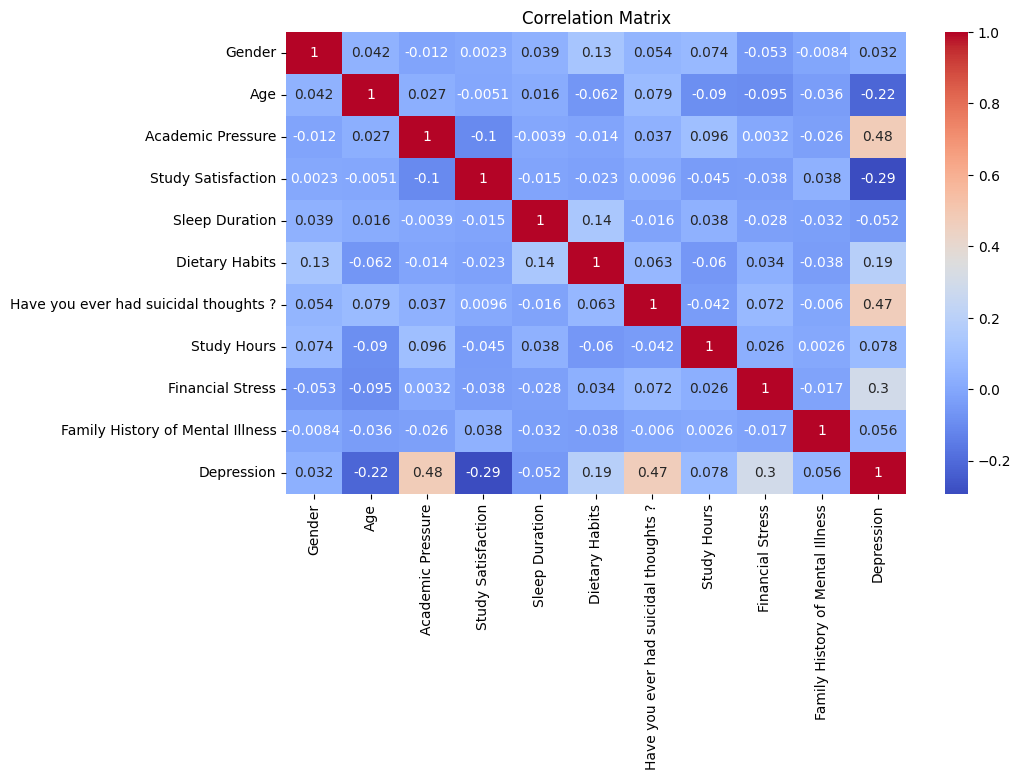

In [15]:
temp = df.copy()

le = LabelEncoder()

for col in temp.columns:
    temp[col] = le.fit_transform(temp[col].astype(str))

plt.figure(figsize=(10,6))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## Transformation

### Label Encoding

In [16]:
# ==================================================
# TRANSFORMATION
# ==================================================

df_encoded = df.copy()

le_dict = {}

for col in df_encoded.columns:

    le = LabelEncoder()

    df_encoded[col] = le.fit_transform(
        df_encoded[col].astype(str)
    )

    le_dict[col] = le

In [17]:
df_encoded.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,10,1,3,1,1,1,12,1,1,0
1,1,10,3,4,0,0,1,10,0,1,0
2,1,7,0,2,0,2,1,2,3,0,1
3,1,5,0,3,3,2,1,10,1,1,0
4,0,13,0,4,3,0,1,7,1,1,0


## Feature Selection

In [18]:
X = df_encoded.drop('Depression', axis=1)

y = df_encoded['Depression']

In [19]:
corr_target = df_encoded.corr()['Depression']

corr_target.sort_values(
    ascending=False
)

,Depression
Depression,1.000000
Academic Pressure,0.476259
Have you ever had suicidal thoughts ?,0.466296
Financial Stress,0.296846
Dietary Habits,0.186685
Study Hours,0.077896
Family History of Mental Illness,0.056087
Gender,0.031683
Sleep Duration,-0.051708
Age,-0.215625


## Split Data

In [20]:
# ==================================================
# SPLIT DATA
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(401, 10)
(101, 10)


## Data Mining

### Model 1 Decision Tree

In [21]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

### Model 2 Random Forest

In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

### Model 3 XGBoost

In [23]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)

## Evaluation

In [24]:
def evaluate_model(name,y_test,y_pred):

    acc = accuracy_score(y_test,y_pred)

    precision = precision_score(y_test,y_pred)

    recall = recall_score(y_test,y_pred)

    f1 = f1_score(y_test,y_pred)

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :",acc)
    print("Precision :",precision)
    print("Recall :",recall)
    print("F1 Score :",f1)

    print()

    print(classification_report(
        y_test,
        y_pred
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)

    plt.show()

Decision Tree
Accuracy : 0.8415841584158416
Precision : 0.8431372549019608
Recall : 0.8431372549019608
F1 Score : 0.8431372549019608

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        50
           1       0.84      0.84      0.84        51

    accuracy                           0.84       101
   macro avg       0.84      0.84      0.84       101
weighted avg       0.84      0.84      0.84       101



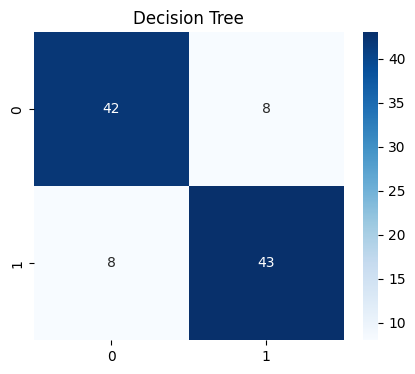

Random Forest
Accuracy : 0.8910891089108911
Precision : 0.8571428571428571
Recall : 0.9411764705882353
F1 Score : 0.897196261682243

              precision    recall  f1-score   support

           0       0.93      0.84      0.88        50
           1       0.86      0.94      0.90        51

    accuracy                           0.89       101
   macro avg       0.90      0.89      0.89       101
weighted avg       0.89      0.89      0.89       101



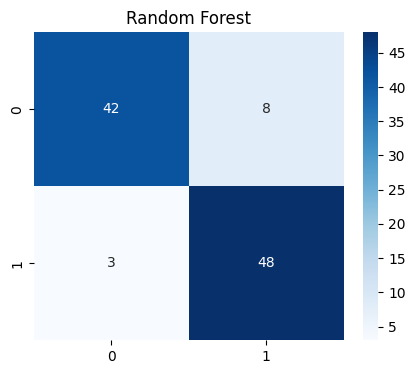

XGBoost
Accuracy : 0.9108910891089109
Precision : 0.875
Recall : 0.9607843137254902
F1 Score : 0.9158878504672897

              precision    recall  f1-score   support

           0       0.96      0.86      0.91        50
           1       0.88      0.96      0.92        51

    accuracy                           0.91       101
   macro avg       0.92      0.91      0.91       101
weighted avg       0.91      0.91      0.91       101



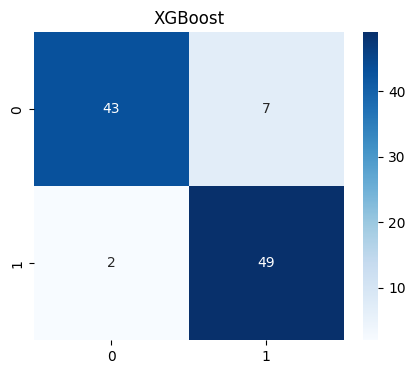

In [25]:
evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb
)

### Perbandingan Akurasi

In [26]:
results = pd.DataFrame({

    'Model':[
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[

        accuracy_score(y_test,y_pred_dt),

        accuracy_score(y_test,y_pred_rf),

        accuracy_score(y_test,y_pred_xgb)

    ]
})

results

,Model,Accuracy
0,Decision Tree,0.841584
1,Random Forest,0.891089
2,XGBoost,0.910891


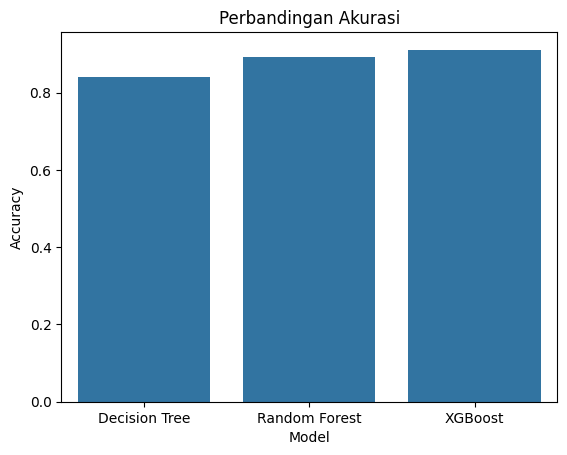

In [27]:
sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Perbandingan Akurasi")

plt.show()

### Feature Importance (Random Forest)

In [28]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,Academic Pressure,0.230487
6,Have you ever had suicidal thoughts ?,0.192561
1,Age,0.133276
3,Study Satisfaction,0.107110
8,Financial Stress,0.102569
7,Study Hours,0.095633
5,Dietary Habits,0.051531
4,Sleep Duration,0.048097
9,Family History of Mental Illness,0.019757
0,Gender,0.018980


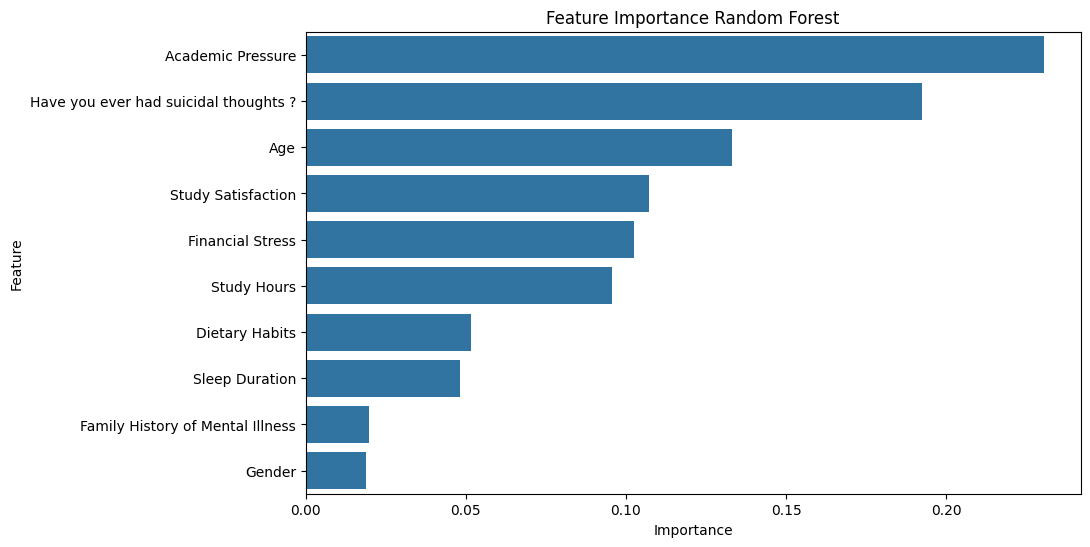

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance Random Forest"
)

plt.show()

In [31]:
best_model = results.iloc[0]

print("Model Terbaik")
print("Nama Model :", best_model['Model'])
print("Accuracy :", round(best_model['Accuracy']*100,2), "%")

Model Terbaik
Nama Model : XGBoost
Accuracy : 91.09 %


In [32]:
print("="*60)
print("KESIMPULAN")
print("="*60)

print(
    f"Model terbaik adalah {best_model['Model']} "
    f"dengan akurasi {round(best_model['Accuracy']*100,2)}%."
)

KESIMPULAN
Model terbaik adalah XGBoost dengan akurasi 91.09%.
